# 长沙电商企业招聘需求分析

## 项目背景

随着电商行业竞争加剧，企业对运营、数据分析及供应链人才的需求持续增长。

本项目通过影刀RPA采集长沙地区头部电商企业公开招聘信息，结合Python进行数据清洗与分析，并通过Power BI进行可视化展示，分析企业招聘需求、薪资水平及技能要求，为求职者职业规划和企业人才招聘提供参考。

---

## 数据来源

数据采集工具：

- 影刀RPA
- 公开招聘信息

分析企业：

- 兴盛优选
- 安克创新
- 水羊股份
- 快乐购(芒果系电商)
- 竞网智赢

数据字段：

- 公司名称
- 岗位名称
- 工作地点
- 学历要求

## 分析目标

1. 统计不同企业招聘岗位数量
2. 分析企业平均薪资水平
3. 识别高薪岗位占比
4. 分析学历要求分布

In [24]:
import pandas as pd 
import matplotlib.pyplot as plt
import re

## 数据清洗

主要处理内容：
- 删除重复数据
- 处理空值
- 统一薪资格式
- 拆分最低薪资与最高薪资

In [25]:
# 设置中文字体和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或 ['Microsoft YaHei'] 微软雅黑 等
plt.rcParams['axes.unicode_minus'] = False 


In [26]:
#封装plt的函数
def PltDef(title,xlabel,ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()

    plt.show()


In [27]:
YD_data = pd.read_excel('../dataSet/CompetitorCompanyData.xlsx')
# print(YD_data.head())
# 删除重复数据
YD_data.drop_duplicates(inplace=True)
# 删除缺失数据
YD_data.dropna(inplace=True)
#处理空值 没有空值
YD_data.isnull().sum()


公司名称    0
职位      0
地点      0
学历      0
薪资      0
薪资下限    0
薪资上限    0
平均薪资    0
年薪      0
dtype: int64

### 薪资格式统一、拆分最低薪资、最高薪资
原始数据薪资字段存在着多种表达方式:
- 6-8k
- 30-45k·16薪
- 6000-8000元
- 1-2万

为了后续的统计分析，对薪资字段进行标准化处理，统一转换为月薪(元)的格式，并拆分为最低薪资、最高薪资、平均薪资、年薪四个阶段

In [34]:
# 对数据进行处理
def Clean_Xinzi(xinzi):
    #默认12薪
    YearXinzi = 12
    # 处理年薪
    year_clean = re.search(r'(\d+)薪', xinzi)
    #替换年薪
    if year_clean:
        YearXinzi = int(year_clean.group(1))
    #删除年薪
    xinzi = re.sub(r'(\d+)薪', '', xinzi)
    # 判断是不是字符串范围内处理薪资范围
    if isinstance(xinzi, str):
        # 判断是否包含万字符
        if '万' in xinzi:
            num = re.findall(r'[\d.]+', xinzi)
            lower =  float(num[0]) * 10000
            upper =  float(num[1]) * 10000
        else:
            # 就是千或者元字符
            num = re.findall(r'[\d.]+', xinzi)
            lower =  float(num[0])
            upper =  float(num[1])
            #这里就是判断是6-8k还是6000-8000
            if lower < 1000:
                lower *= 1000
                upper *= 1000
        # 计算平均薪资和年薪
        Avg_price = (lower + upper) / 2
        YearXinziPrice = Avg_price * YearXinzi
    # 把多个返回值之变成多列数据
    return pd.Series(
        [
            lower,
            upper,
            Avg_price,
            YearXinziPrice
        ]
    )
# 应用函数到数据框的薪资列，并将结果分配给新的列
YD_data[['薪资下限', '薪资上限', '平均薪资', '年薪']] = YD_data['薪资'].apply(Clean_Xinzi)
# print(YD_data[['薪资下限', '薪资上限', '平均薪资', '年薪']].head())

## 一、岗位数量对比分析

分析不同企业当前招聘岗位数量情况。

重点关注：

- 哪家公司招聘需求最高
- 企业扩张趋势

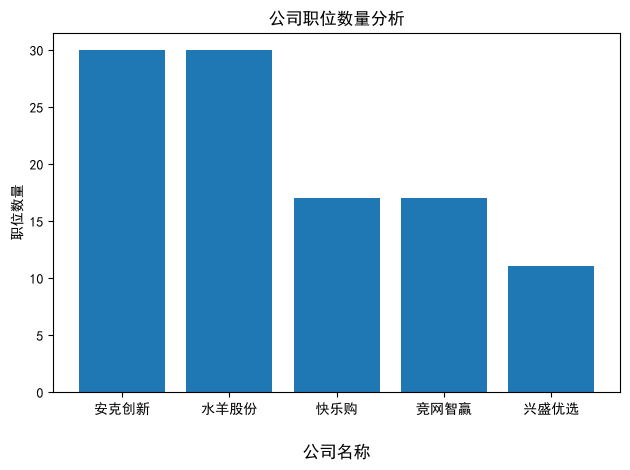

In [29]:
# 统计每个公司的职位数量 
#reset_index(name='职位数量') 是为了将职位数量列命名为 '职位数量'，并将结果转换为一个新的 DataFrame。
#sort_values(ascending=False) 是为了按照职位数量从高到低排序。
ComJobAnalysis = YD_data.groupby('公司名称')["职位"].count().sort_values(ascending=False).reset_index(name='职位数量')

# 绘制公司职位数量的柱状图
#设置一下x轴距离太近 影响美感 
# subplot() 方法在绘图时需要指定位置，subplots() 方法可以一次生成多个，在调用时只需要调用生成对象的 ax 属性即可。
fig, ax = plt.subplots()   
plt.bar(ComJobAnalysis['公司名称'], ComJobAnalysis['职位数量'])
ax.set_xlabel('xlabel',fontsize=12,labelpad=20)
PltDef('公司职位数量分析','公司名称','职位数量')


## 二、薪资分布分析

分析内容：

- 平均薪资
- 最高薪资
- 最低薪资
- 高薪岗位占比

评价不同企业的人才投入水平。

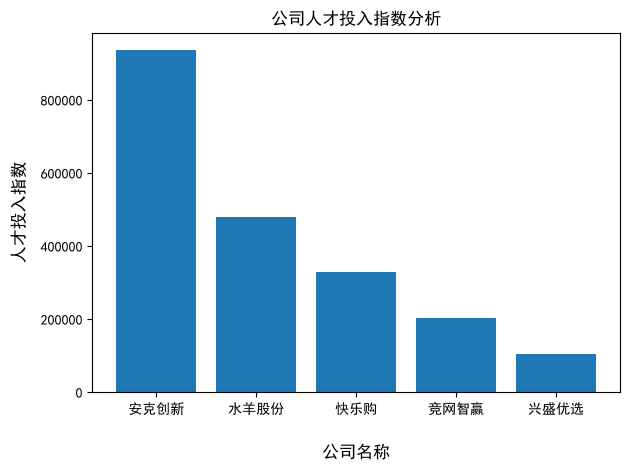

In [30]:
# 统计每个公司的平均薪资
ComAvgSalary = YD_data.groupby('公司名称')["平均薪资"].mean().reset_index(name='平均薪资')
 
#merge函数将ComAvgSalary(公司平均薪资)和ComJobAnalysis(公司职位数量)两个数据框进行合并，生成一个新的数据框TalentInvestment。
#参数on='公司名称'指定了合并的键，即根据'公司名称'列进行合并。
#共同关键字'公司名称'在两个数据框中都存在，merge函数会将它们匹配起来，并将对应的平均薪资和职位数量合并到新的数据框TalentInvestment中。
TalentInvestment = pd.merge(ComAvgSalary, ComJobAnalysis, on='公司名称')

#根据公司平均薪资和职位数量计算人才投入指数，公式为：人才投入指数 = 平均薪资 * 职位数量。
TalentInvestment['人才投入指数'] = TalentInvestment['平均薪资'] * TalentInvestment['职位数量']
#根据人才投入指数对公司进行排序
TalentInvestment = TalentInvestment.sort_values(by='人才投入指数', ascending=False)

# 绘制公司人才投入指数的柱状图
fig, ax = plt.subplots()   
plt.bar(TalentInvestment['公司名称'], TalentInvestment['人才投入指数'])
ax.set_xlabel('xlabel',fontsize=12,labelpad=20)
ax.set_ylabel('ylabel',fontsize=12,labelpad=10)
PltDef('公司人才投入指数分析','公司名称','人才投入指数')

## 三、学历要求分析

统计：

- 大专
- 本科
- 硕士
- 学历不限

占比情况。

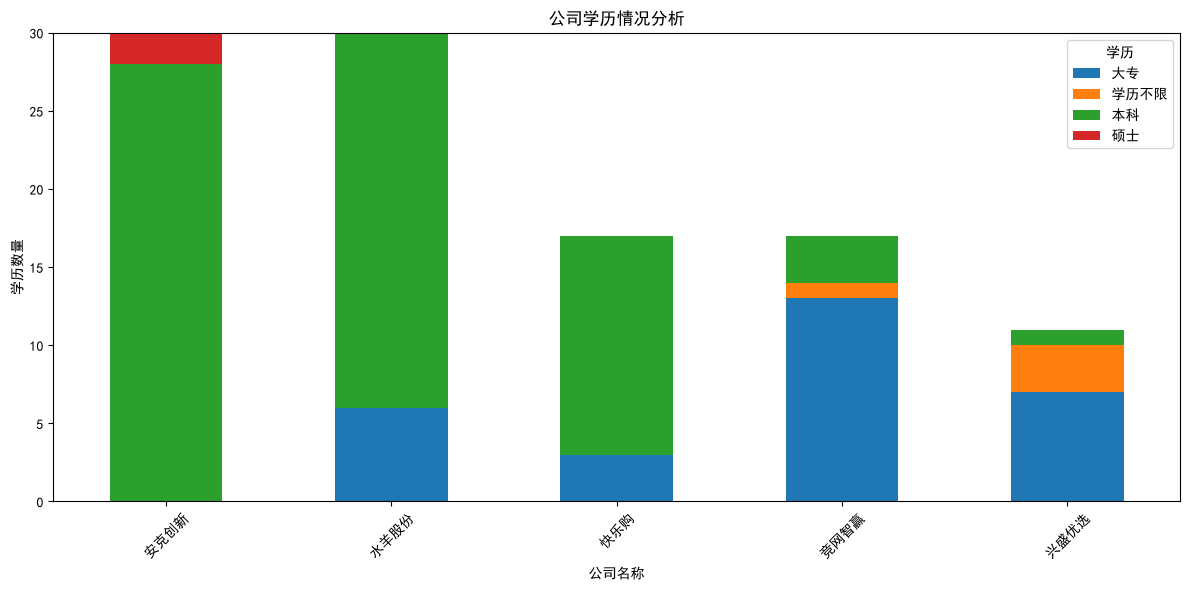

In [31]:
#更改学历类型
YD_data['学历'] = YD_data['学历'].replace({
    '本科': '本科',
    '统招本科': '本科'
})

# 统计每个公司的学历数量
EduBackAnalysis = YD_data.groupby("公司名称")["学历"].value_counts().reset_index(name='学历数量')

#绘制公司学历情况的透视表
EduBackPivot = pd.pivot_table(
    EduBackAnalysis, 
    #index参数指定了透视表的行索引，这里是'公司名称'，表示每一行对应一个公司。
    index='公司名称', 
    #columns参数指定了透视表的列索引，这里是'学历'，表示每一列对应一个学历类型。
    columns='学历', 
    #values参数指定了透视表中填充的数据，这里是'学历数量'，表示每个公司对应的每种学历类型的数量。
    values='学历数量',
    #fill_value参数指定了在透视表中缺失值的填充值，这里设置为0，表示如果某个公司没有某种学历类型的数据，则填充为0。
    fill_value=0
)

#计算每个公司的总学历数量，并将其添加为透视表的一列。
# axis=1表示按行计算总和，即对每个公司的学历数量进行求和，得到每个公司的总学历数量。
EduBackPivot["总数"] = EduBackPivot.sum(axis=1)
#根据总学历数量对公司进行排序，ascending=False表示降序排序，即总学历数量较多的公司排在前面。
EduBackPivot = EduBackPivot.sort_values(by='总数', ascending=False)
#删除总数列，因为我们只需要每个学历类型的数量来绘制堆叠柱状图，而总数列只是为了排序而添加的，不需要在图表中显示。
EduBackPivot.drop(columns='总数', inplace=True)

#stacked 柱状堆叠图 
EduBackPivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xticks(rotation=45, ha='center')
PltDef('公司学历情况分析','公司名称','学历数量')



## 项目工具

- 影刀RPA
- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- Power BI

In [32]:
#index 不将行索引添加进去
YD_data.to_excel("../dataSet/CompetitorCompanyData.xlsx",index=False)

## 项目结论
 1. 本科学历仍为主流要求。
 2. 大企业对于人才的投入占比较高
 3. 企业发展越大，招聘的岗位也就越多，对于人才的需求也就越高